In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from heapq import heappush, heappop
from scipy import stats as stats

In [2]:
def run_simulation(n_A: int, n_B: int, n_C: int, n_rep: int = 500, los_dist: str = 'lognormal') -> dict:
    np.random.seed(42)
    T   = 365.0

    sig  = np.sqrt(np.log(2))
    mu   = np.array([np.log(4*np.sqrt(2)), np.log(6*np.sqrt(2)), np.log(5*np.sqrt(2))])
    exp_mean = np.array([8.0, 12.0, 10.0])

    def lam1(t: float) -> float:
        return max(0.0, -(1.0/3650)*t*t + 0.1*t)

    lam_max1 = lam1(182.5)
    lam_max2 = lam_max1 / 5.0
    lam3     = 6.0

    caps = np.array([n_A, n_B, n_C], dtype=float)

    rp_full  = np.zeros((n_rep, 3))
    rp_reloc = np.zeros((n_rep, 3))
    rp_util  = np.zeros((n_rep, 3))

    for rep in range(n_rep):

        events = []
        t = 0.0
        while True:
            t += np.random.exponential(1.0 / lam_max1)
            if t >= T: break
            if np.random.random() <= lam1(t) / lam_max1:
                events.append((t, 0))

        t = 0.0
        while True:
            t += np.random.exponential(1.0 / lam_max2)
            if t >= T: break
            if np.random.random() <= lam1(t) / lam_max1:
                events.append((t, 1))


        t = 0.0
        while True:
            t += np.random.exponential(1.0 / lam3)
            if t >= T: break
            events.append((t, 2))

        events.sort()

        occ   = [0, 0, 0]
        n_arr = [0, 0, 0]
        n_ful = [0, 0, 0]   
        n_rel = [0, 0, 0]
        area  = [0.0, 0.0, 0.0]

        deps  = []
        cur   = 0.0
        ei    = 0
        ne    = len(events)

        while True:
            ta = events[ei][0] if ei < ne  else 1e18
            td = deps[0][0]    if deps      else 1e18
            tn = min(ta, td, T)

            dt       = tn - cur
            area[0] += occ[0] * dt
            area[1] += occ[1] * dt
            area[2] += occ[2] * dt
            cur      = tn

            if cur >= T:
                break

            if ta <= td:
                _, pt = events[ei]; ei += 1
                n_arr[pt] += 1

                if los_dist == 'lognormal':
                    los_fn = lambda i: np.random.lognormal(mu[i], sig)
                else:
                    los_fn = lambda i: np.random.exponential(exp_mean[i])

                if pt == 0:
                    if occ[0] < n_A:
                        occ[0] += 1
                        heappush(deps, (cur + los_fn(0), 0))
                    else:
                        n_ful[0] += 1
                        n_rel[0] += 1

                elif pt == 1:
                    if occ[1] < n_B:
                        occ[1] += 1
                        heappush(deps, (cur + los_fn(1), 1))
                    else:
                        n_ful[1] += 1
                        if occ[0] < n_A:
                            occ[0] += 1
                            heappush(deps, (cur + los_fn(1), 0))
                        else:
                            n_rel[1] += 1

                else:
                    if occ[2] < n_C:
                        occ[2] += 1
                        heappush(deps, (cur + los_fn(2), 2))
                    else:
                        n_ful[2] += 1
                        n_rel[2] += 1

            else:
                _, wi = heappop(deps)
                occ[wi] -= 1

        for i in range(3):
            rp_full[rep, i]  = n_ful[i] / max(n_arr[i], 1)
            rp_reloc[rep, i] = n_rel[i]
            rp_util[rep, i]  = area[i] / (T * caps[i])

    def ci95(arr2d):
        m  = arr2d.mean(axis=0)
        hc = 1.96 * arr2d.std(axis=0) / np.sqrt(n_rep)
        return m, hc

    tot = rp_reloc.sum(axis=1)
    return dict(
        p_full      = ci95(rp_full),
        reloc       = ci95(rp_reloc),
        util        = ci95(rp_util),
        total_reloc = (tot.mean(), 1.96 * tot.std() / np.sqrt(n_rep)),
    )

In [3]:
def f(val, ci, pct=False):
    s = 100 if pct else 1
    u = '%' if pct else ''
    return f"{val*s:7.2f} +- {ci*s:.2f}{u}"


def print_results(r: dict, nA: int, nB: int, nC: int, title: str = ""):
    pm, pci = r['p_full']
    rm, rci = r['reloc']
    um, uci = r['util']
    tm, tci = r['total_reloc']

    if title:
        print(f"{title}")
    print(f"Beds:  A={nA},  B={nB},  C={nC}   (total = {nA+nB+nC})\n")
    print(f"P(primary ward full on arrival):")
    print(f"    Ward A : {f(pm[0], pci[0], True)}")
    print(f"    Ward B : {f(pm[1], pci[1], True)}")
    print(f"    Ward C : {f(pm[2], pci[2], True)}")
    print(f"Mean relocations per year:")
    print(f"    Ward A : {f(rm[0], rci[0])}")
    print(f"    Ward B : {f(rm[1], rci[1])}")
    print(f"    Ward C : {f(rm[2], rci[2])}")
    print(f"    Total  : {f(tm,    tci)}")
    print(f"Mean bed utilisation:")
    print(f"    Ward A : {f(um[0], uci[0], True)}")
    print(f"    Ward B : {f(um[1], uci[1], True)}")
    print(f"    Ward C : {f(um[2], uci[2], True)}")


In [4]:
TOTAL     = 75
N_PRIMARY = 1000
N_SWEEP   = 100
N_SENS    = 1000
N_BEDS    = 500

nA0, nB0, nC0 = 20, 5, 50

print(f"Primary analysis  ({N_PRIMARY} reps, lognormal LOS)\n")
r_prim = run_simulation(nA0, nB0, nC0, n_rep=N_PRIMARY, los_dist='lognormal')
print_results(r_prim, nA0, nB0, nC0, "Primary Analysis, Lognormal LOS")

Primary analysis  (1000 reps, lognormal LOS)

Primary Analysis, Lognormal LOS
Beds:  A=20,  B=5,  C=50   (total = 75)

P(primary ward full on arrival):
    Ward A :   68.59 +- 0.08%
    Ward B :   70.32 +- 0.16%
    Ward C :   20.67 +- 0.12%
Mean relocations per year:
    Ward A : 1524.28 +- 3.02
    Ward B :  227.23 +- 1.14
    Ward C :  453.24 +- 3.14
    Total  : 2204.75 +- 4.67
Mean bed utilisation:
    Ward A :   89.97 +- 0.06%
    Ward B :   84.81 +- 0.13%
    Ward C :   92.66 +- 0.04%


In [5]:
print(f"Bed-distribution sweep ({N_SWEEP} reps per config)")

nB_range = range(1, 16)
nC_range = range(30, 71, 5)
sweep    = {}

for nB in nB_range:
    for nC in nC_range:
        nA = TOTAL - nB - nC
        if nA < 1:
            continue
        r = run_simulation(nA, nB, nC, n_rep=N_SWEEP)
        sweep[(nA, nB, nC)] = r['total_reloc'][0]

opt_key  = min(sweep, key=sweep.get)
nA_opt, nB_opt, nC_opt = opt_key
print(f"\nOptimal (sweep): A={nA_opt}, B={nB_opt}, C={nC_opt}" f" - total reloc aprox {sweep[opt_key]:.1f}")

r_opt = run_simulation(nA_opt, nB_opt, nC_opt, n_rep=N_PRIMARY)
print_results(r_opt, nA_opt, nB_opt, nC_opt, "Optimal Bed Distribution")

Bed-distribution sweep (100 reps per config)

Optimal (sweep): A=34, B=1, C=40 - total reloc aprox 2134.3
Optimal Bed Distribution
Beds:  A=34,  B=1,  C=40   (total = 75)

P(primary ward full on arrival):
    Ward A :   52.00 +- 0.10%
    Ward B :   93.75 +- 0.07%
    Ward C :   34.94 +- 0.12%
Mean relocations per year:
    Ward A : 1155.34 +- 3.24
    Ward B :  220.57 +- 1.05
    Ward C :  765.40 +- 3.44
    Total  : 2141.31 +- 5.07
Mean bed utilisation:
    Ward A :   86.89 +- 0.06%
    Ward B :   89.43 +- 0.15%
    Ward C :   94.92 +- 0.03%


In [6]:
print(f"LOS sensitivity ({N_SENS} reps, same beds as primary)\n")
r_exp = run_simulation(nA0, nB0, nC0, n_rep=N_SENS, los_dist='exponential')
print_results(r_exp, nA0, nB0, nC0, "Exponential LOS (same bed distribution as primary)")

LOS sensitivity (1000 reps, same beds as primary)

Exponential LOS (same bed distribution as primary)
Beds:  A=20,  B=5,  C=50   (total = 75)

P(primary ward full on arrival):
    Ward A :   68.58 +- 0.08%
    Ward B :   70.50 +- 0.16%
    Ward C :   20.65 +- 0.13%
Mean relocations per year:
    Ward A : 1523.33 +- 3.23
    Ward B :  227.64 +- 1.16
    Ward C :  452.74 +- 3.27
    Total  : 2203.71 +- 4.84
Mean bed utilisation:
    Ward A :   89.94 +- 0.06%
    Ward B :   84.80 +- 0.13%
    Ward C :   92.47 +- 0.05%


In [7]:
r_opt_exp = run_simulation(nA_opt, nB_opt, nC_opt, n_rep=N_SENS, los_dist='exponential')
print_results(r_opt_exp, nA_opt, nB_opt, nC_opt,"Exponential LOS  (optimal bed distribution)")

Exponential LOS  (optimal bed distribution)
Beds:  A=34,  B=1,  C=40   (total = 75)

P(primary ward full on arrival):
    Ward A :   52.18 +- 0.10%
    Ward B :   93.78 +- 0.07%
    Ward C :   34.95 +- 0.12%
Mean relocations per year:
    Ward A : 1159.39 +- 3.11
    Ward B :  220.40 +- 1.03
    Ward C :  765.39 +- 3.43
    Total  : 2145.18 +- 4.91
Mean bed utilisation:
    Ward A :   86.88 +- 0.06%
    Ward B :   89.45 +- 0.15%
    Ward C :   94.80 +- 0.03%


In [8]:
print(f"Total-bed sensitivity  ({N_BEDS} reps each)")
bed_totals = [50, 60, 65, 70, 75, 80, 90, 100]
beds_res   = []

for tot in bed_totals:
    nA = max(1, round(nA0 / TOTAL * tot))
    nB = max(1, round(nB0 / TOTAL * tot))
    nC = max(1, tot - nA - nB)
    r  = run_simulation(nA, nB, nC, n_rep=N_BEDS)
    tm, tci = r['total_reloc']
    beds_res.append((tot, nA, nB, nC, tm, tci,
                    r['util'][0].copy(), r['util'][1].copy()))
    print(f"    beds={tot:3d}  (A={nA:2d}, B={nB:2d}, C={nC:2d}):  "
        f"reloc = {tm:6.1f} +- {tci:.1f}")


Total-bed sensitivity  (500 reps each)
    beds= 50  (A=13, B= 3, C=34):  reloc = 3030.3 +- 7.0
    beds= 60  (A=16, B= 4, C=40):  reloc = 2687.3 +- 6.6
    beds= 65  (A=17, B= 4, C=44):  reloc = 2519.6 +- 7.0
    beds= 70  (A=19, B= 5, C=46):  reloc = 2362.4 +- 6.8
    beds= 75  (A=20, B= 5, C=50):  reloc = 2203.0 +- 6.5
    beds= 80  (A=21, B= 5, C=54):  reloc = 2055.1 +- 6.6
    beds= 90  (A=24, B= 6, C=60):  reloc = 1778.2 +- 6.1
    beds=100  (A=27, B= 7, C=66):  reloc = 1540.8 +- 5.5


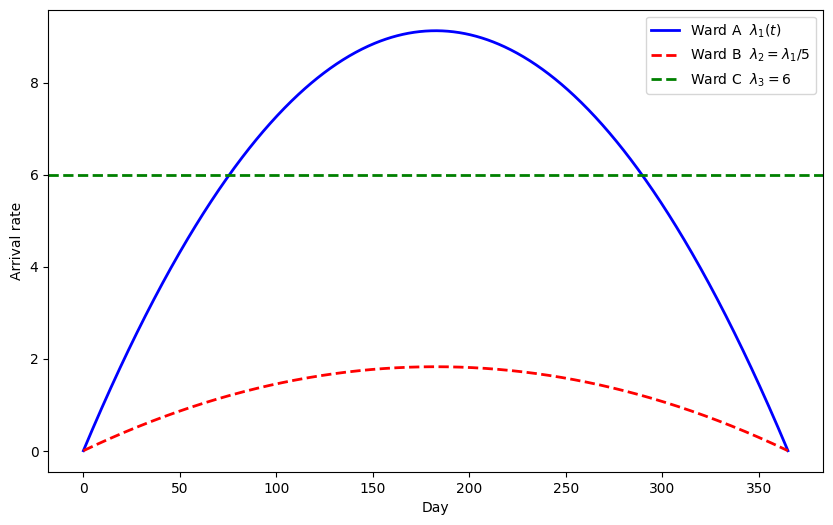

In [9]:
fig, ax = plt.subplots(1,1, figsize=(10, 6))

tv  = np.linspace(0, 365, 1000)
l1v = np.maximum(0, -(1/3650)*tv**2 + 0.1*tv)

# Use ax[row, col] for each subplot:
ax.plot(tv, l1v,   'b-',  lw=2, label=r'Ward A  $\lambda_1(t)$')
ax.plot(tv, l1v/5, 'r--', lw=2, label=r'Ward B  $\lambda_2 = \lambda_1/5$')
ax.axhline(6, color='g', ls='--', lw=2, label=r'Ward C  $\lambda_3 = 6$')
ax.set(xlabel='Day', ylabel='Arrival rate')
ax.legend()

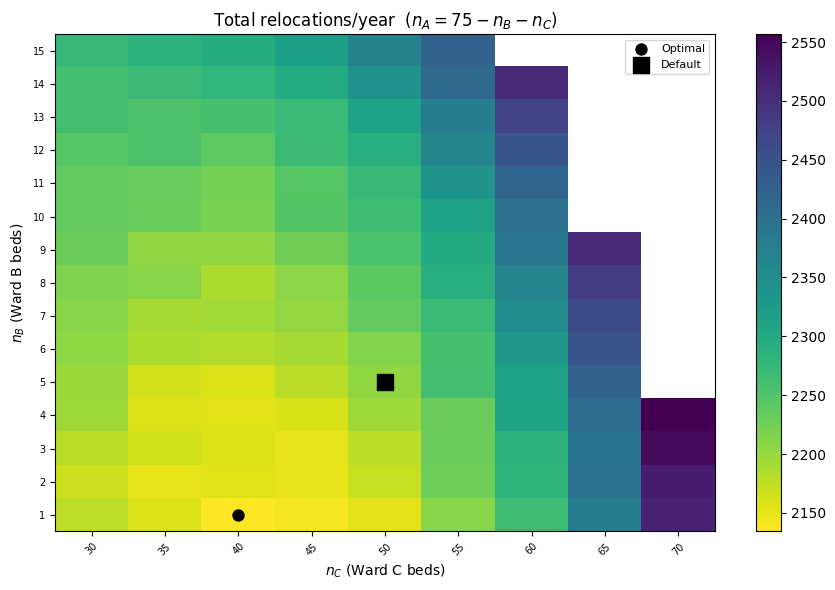

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))

nBv = sorted(set(k[1] for k in sweep))
nCv = sorted(set(k[2] for k in sweep))
Z   = np.full((len(nBv), len(nCv)), np.nan)
for i, nb in enumerate(nBv):
    for j, nc in enumerate(nCv):
        na = TOTAL - nb - nc
        if na >= 1 and (na, nb, nc) in sweep:
            Z[i, j] = sweep[(na, nb, nc)]

im = ax.imshow(Z, aspect='auto', origin='lower', cmap='viridis_r')
ax.set_xticks(range(len(nCv)));  ax.set_xticklabels(nCv, rotation=45, fontsize=7)
ax.set_yticks(range(len(nBv)));  ax.set_yticklabels(nBv, fontsize=7)
ax.set(xlabel='$n_C$ (Ward C beds)', ylabel='$n_B$ (Ward B beds)', title=f'Total relocations/year  ($n_A = {TOTAL}-n_B-n_C$)')
ax.scatter([nCv.index(nC_opt)], [nBv.index(nB_opt)], marker='.', s=250, c='black', zorder=6, label='Optimal')
ax.scatter([nCv.index(nC0)], [nBv.index(nB0)], marker='s', s=120, c='black', zorder=6, label='Default')
ax.legend(fontsize=8)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

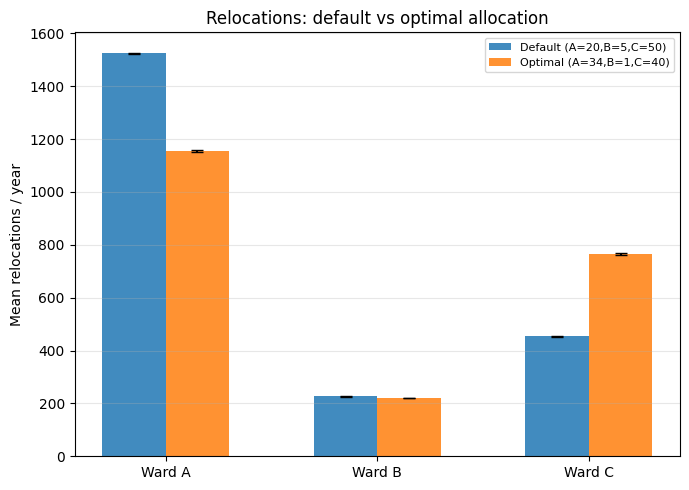

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

cats  = ['Ward A', 'Ward B', 'Ward C']
x     = np.arange(3);  w = 0.30
rm_p, rci_p = r_prim['reloc']
rm_o, rci_o = r_opt['reloc']
ax.bar(x-w/2, rm_p, w, yerr=rci_p, capsize=4, alpha=0.85, label=f'Default (A={nA0},B={nB0},C={nC0})')
ax.bar(x+w/2, rm_o, w, yerr=rci_o, capsize=4, alpha=0.85, label=f'Optimal (A={nA_opt},B={nB_opt},C={nC_opt})')
ax.set(xticks=x, xticklabels=cats, ylabel='Mean relocations / year', title='Relocations: default vs optimal allocation')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

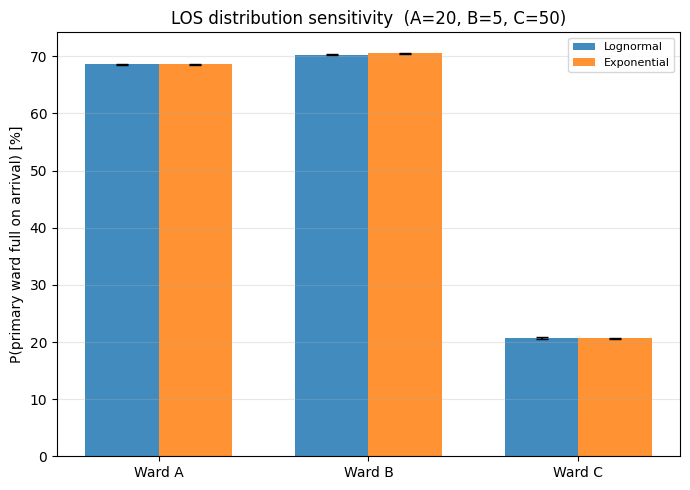

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

cats = ['Ward A', 'Ward B', 'Ward C']
pm_l, pci_l = r_prim['p_full']
pm_e, pci_e = r_exp['p_full']
x = np.arange(3);  w = 0.35
ax.bar(x-w/2, pm_l*100, w, yerr=pci_l*100, capsize=4, alpha=0.85, label='Lognormal')
ax.bar(x+w/2, pm_e*100, w, yerr=pci_e*100, capsize=4, alpha=0.85, label='Exponential')
ax.set(xticks=x, xticklabels=cats, ylabel='P(primary ward full on arrival) [%]', title=f'LOS distribution sensitivity  (A={nA0}, B={nB0}, C={nC0})')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


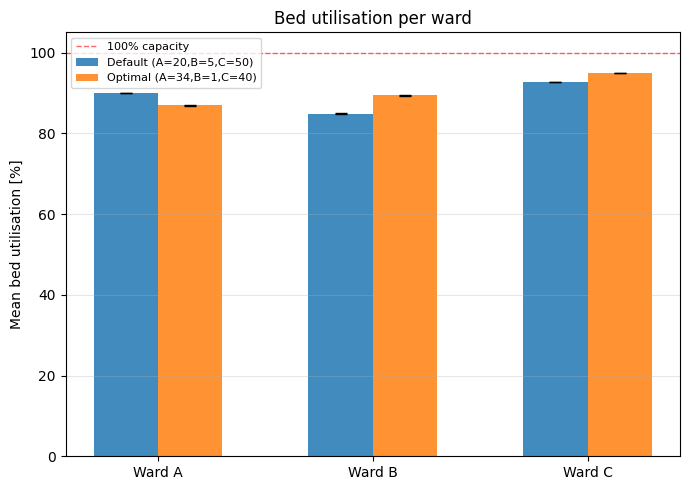

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))

wards = ['Ward A', 'Ward B', 'Ward C']
x     = np.arange(3);  w = 0.30
um_p, uci_p = r_prim['util']
um_o, uci_o = r_opt['util']
ax.bar(x-w/2, um_p*100, w, yerr=uci_p*100, capsize=4, alpha=0.85, label=f'Default (A={nA0},B={nB0},C={nC0})')
ax.bar(x+w/2, um_o*100, w, yerr=uci_o*100, capsize=4, alpha=0.85, label=f'Optimal (A={nA_opt},B={nB_opt},C={nC_opt})')
ax.axhline(100, color='red', ls='--', lw=1, alpha=0.6, label='100% capacity')
ax.set(xticks=x, xticklabels=wards, ylabel='Mean bed utilisation [%]', title='Bed utilisation per ward')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

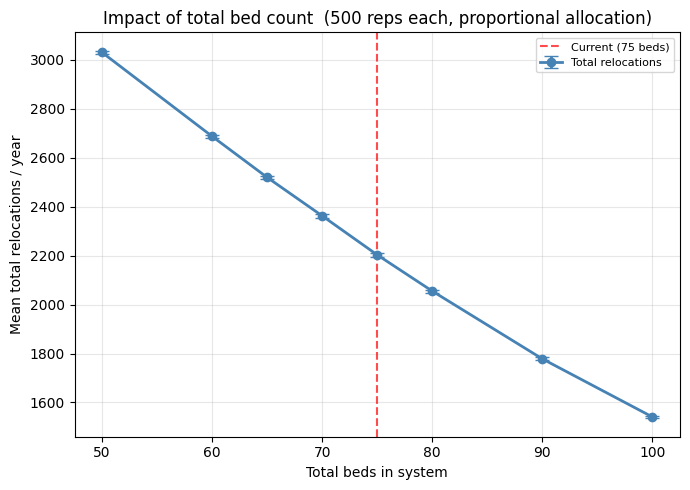

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

tots   = [b[0] for b in beds_res]
relocs = [b[4] for b in beds_res]
cis    = [b[5] for b in beds_res]
ax.errorbar(tots, relocs, yerr=cis, marker='o', lw=2, capsize=5, color='steelblue', label='Total relocations')
ax.axvline(75, color='red', ls='--', alpha=0.7, label='Current (75 beds)')
ax.set(xlabel='Total beds in system', ylabel='Mean total relocations / year', title=f'Impact of total bed count  ({N_BEDS} reps each, proportional allocation)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
def raw_reloc(n_A, n_B, n_C, n_rep=1000, los_dist='lognormal'):
    np.random.seed(42)
    T = 365.0
    sig = np.sqrt(np.log(2))
    mu  = np.array([np.log(4*np.sqrt(2)), np.log(6*np.sqrt(2)), np.log(5*np.sqrt(2))])
    exp_mean = np.array([8., 12., 10.])

    def lam1(t): return max(0., -(1/3650)*t*t + 0.1*t)
    lam_max1 = lam1(182.5); lam_max2 = lam_max1/5; lam3 = 6.

    totals = np.zeros(n_rep)
    for rep in range(n_rep):
        events = []
        t = 0.
        while True:
            t += np.random.exponential(1/lam_max1)
            if t >= T: break
            if np.random.random() <= lam1(t)/lam_max1: events.append((t, 0))
        t = 0.
        while True:
            t += np.random.exponential(1/lam_max2)
            if t >= T: break
            if np.random.random() <= lam1(t)/lam_max1: events.append((t, 1))
        t = 0.
        while True:
            t += np.random.exponential(1/lam3)
            if t >= T: break
            events.append((t, 2))
        events.sort()

        occ = [0,0,0]; n_rel = [0,0,0]; deps = []; cur = 0.; ei = 0; ne = len(events)
        while True:
            ta = events[ei][0] if ei < ne else 1e18
            td = deps[0][0]    if deps    else 1e18
            tn = min(ta, td, T)
            cur = tn
            if cur >= T: break
            if ta <= td:
                _, pt = events[ei]; ei += 1
                los_fn = (lambda i: np.random.lognormal(mu[i], sig)) if los_dist=='lognormal' \
                         else (lambda i: np.random.exponential(exp_mean[i]))
                if pt == 0:
                    if occ[0] < n_A: occ[0]+=1; heappush(deps,(cur+los_fn(0),0))
                    else: n_rel[0]+=1
                elif pt == 1:
                    if occ[1] < n_B: occ[1]+=1; heappush(deps,(cur+los_fn(1),1))
                    else:
                        if occ[0] < n_A: occ[0]+=1; heappush(deps,(cur+los_fn(1),0))
                        else: n_rel[1]+=1
                else:
                    if occ[2] < n_C: occ[2]+=1; heappush(deps,(cur+los_fn(2),2))
                    else: n_rel[2]+=1
            else:
                _, wi = heappop(deps); occ[wi]-=1
        totals[rep] = sum(n_rel)
    return totals

def cohens_d(a, b):
    pooled_std = np.sqrt((a.std(ddof=1)**2 + b.std(ddof=1)**2) / 2)
    return (a.mean() - b.mean()) / pooled_std

In [16]:
raw_def = raw_reloc(20, 5, 50, n_rep=1000)
raw_opt = raw_reloc(34, 1, 40, n_rep=1000)

t, p = stats.ttest_ind(raw_def, raw_opt, equal_var=False)
d = cohens_d(raw_def, raw_opt)
print(f"  Default : {raw_def.mean():.1f} ± {raw_def.std():.1f}")
print(f"  Optimal : {raw_opt.mean():.1f} ± {raw_opt.std():.1f}")
print(f"  Welch t = {t:.3f},  p = {p:.2}")
print(f"  Cohen's d = {d:.3f}  ({'large' if abs(d)>0.8 else 'medium' if abs(d)>0.5 else 'small'})")

  Default : 2204.8 ± 75.3
  Optimal : 2141.3 ± 81.8
  Welch t = 18.030,  p = 2e-67
  Cohen's d = 0.806  (large)


In [17]:
raw_ln  = raw_reloc(20, 5, 50, n_rep=1000, los_dist='lognormal')
raw_exp = raw_reloc(20, 5, 50, n_rep=1000, los_dist='exponential')

t, p = stats.ttest_ind(raw_ln, raw_exp, equal_var=False)
d    = cohens_d(raw_ln, raw_exp)
print(f"  Lognormal   : {raw_ln.mean():.1f} ± {raw_ln.std():.1f}")
print(f"  Exponential : {raw_exp.mean():.1f} ± {raw_exp.std():.1f}")
print(f"  Welch t = {t:.3f},  p = {p:.2}")
print(f"  Cohen's d = {d:.3f}  ({'large' if abs(d)>0.8 else 'medium' if abs(d)>0.5 else 'small'})")


  Lognormal   : 2204.8 ± 75.3
  Exponential : 2203.7 ± 78.1
  Welch t = 0.303,  p = 0.76
  Cohen's d = 0.014  (small)


In [18]:
bed_totals = [50, 60, 65, 70, 75, 80, 90, 100]
groups = []
for tot in bed_totals:
    nA = max(1, round(20/75*tot)); nB = max(1, round(5/75*tot)); nC = max(1, tot-nA-nB)
    g = raw_reloc(nA, nB, nC, n_rep=300)
    groups.append(g)
    print(f"  beds={tot:3d}: mean={g.mean():.1f}, std={g.std():.1f}")

F, p = stats.f_oneway(*groups)
print(f"\n  F = {F:.1f},  p = {p:.2}")

  beds= 50: mean=3030.1, std=78.6
  beds= 60: mean=2683.4, std=75.0
  beds= 65: mean=2515.6, std=77.9
  beds= 70: mean=2358.3, std=78.4
  beds= 75: mean=2203.6, std=72.8
  beds= 80: mean=2057.4, std=74.5
  beds= 90: mean=1777.9, std=66.4
  beds=100: mean=1540.9, std=64.6

  F = 12898.6,  p = 0.0


In [19]:
m = len(groups) - 1
for i in range(m):
    t, p_raw = stats.ttest_ind(groups[i], groups[i+1], equal_var=False)
    p_corr   = min(p_raw * m, 1.0)
    sig      = "***" if p_corr < 0.001 else "**" if p_corr < 0.01 else "*" if p_corr < 0.05 else "ns"
    print(f"{bed_totals[i]:3d} vs {bed_totals[i+1]:3d}: " f"t={t:6.2f}, p_adj={p_corr:.3f}  {sig}")

print("'***' if p_corr < 0.001 else '**' if p_corr < 0.01 else '*' if p_corr < 0.05 else 'ns'")

 50 vs  60: t= 55.15, p_adj=0.000  ***
 60 vs  65: t= 26.83, p_adj=0.000  ***
 65 vs  70: t= 24.62, p_adj=0.000  ***
 70 vs  75: t= 25.00, p_adj=0.000  ***
 75 vs  80: t= 24.27, p_adj=0.000  ***
 80 vs  90: t= 48.44, p_adj=0.000  ***
 90 vs 100: t= 44.24, p_adj=0.000  ***
'***' if p_corr < 0.001 else '**' if p_corr < 0.01 else '*' if p_corr < 0.05 else 'ns'



  Default vs Optimal:
    KS statistic = 0.3340,  p = 8.6e-50

  Lognormal vs Exponential LOS:
    KS statistic = 0.0440,  p = 0.29


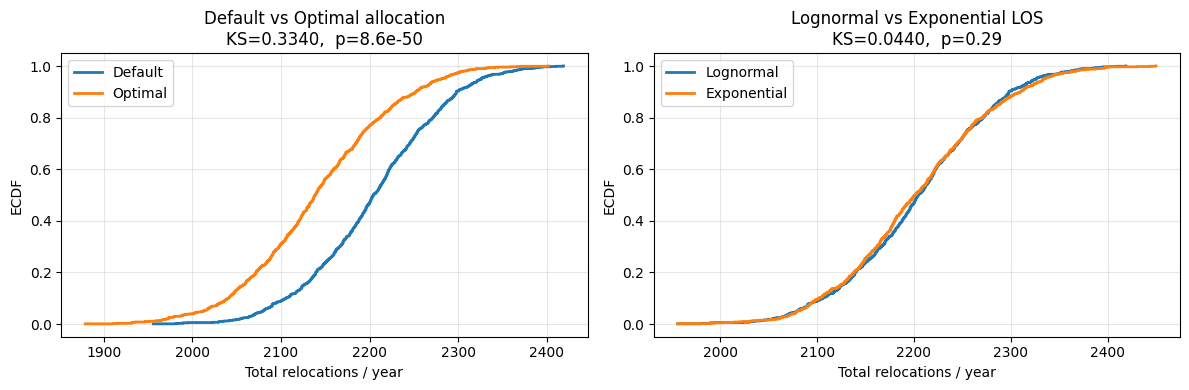

In [20]:
ks_stat, ks_p = stats.ks_2samp(raw_def, raw_opt)
print(f"\n  Default vs Optimal:")
print(f"    KS statistic = {ks_stat:.4f},  p = {ks_p:.2}")

ks_stat, ks_p = stats.ks_2samp(raw_ln, raw_exp)
print(f"\n  Lognormal vs Exponential LOS:")
print(f"    KS statistic = {ks_stat:.4f},  p = {ks_p:.2}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (a, b, la, lb, title) in zip(axes, [
    (raw_def, raw_opt, 'Default', 'Optimal',      'Default vs Optimal allocation'),
    (raw_ln,  raw_exp, 'Lognormal', 'Exponential','Lognormal vs Exponential LOS'),
]):
    for sample, label in [(a, la), (b, lb)]:
        x = np.sort(sample)
        y = np.arange(1, len(x)+1) / len(x)
        ax.step(x, y, where='post', label=label, lw=2)
    ks, p = stats.ks_2samp(a, b)
    ax.set(xlabel='Total relocations / year', ylabel='ECDF',
           title=f'{title}\nKS={ks:.4f},  p={p:.2}')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
for label, sample in [('Default (lognormal)', raw_def),
                       ('Optimal (lognormal)', raw_opt),
                       ('Default (exponential)', raw_exp)]:
    mu_hat = sample.mean()
    lo, hi = int(sample.min()), int(sample.max())
    bins   = np.arange(lo, hi + 2)
    obs, _ = np.histogram(sample, bins=bins)
    exp    = len(sample) * (stats.poisson.pmf(bins[:-1], mu_hat))

    while exp[0] < 5 and len(exp) > 2:
        obs = np.concatenate([[obs[0]+obs[1]], obs[2:]])
        exp = np.concatenate([[exp[0]+exp[1]], exp[2:]])
        bins = bins[1:]
    while exp[-1] < 5 and len(exp) > 2:
        obs = np.concatenate([obs[:-2], [obs[-2]+obs[-1]]])
        exp = np.concatenate([exp[:-2], [exp[-2]+exp[-1]]])

    exp  = exp / exp.sum() * obs.sum()
    chi2, p = stats.chisquare(obs, f_exp=exp, ddof=1)
    print(f"\n{label}:")
    print(f"mean={mu_hat:.1f},  chi2={chi2:.2f},  df={len(obs)-2},  p={p:.2}")
    print(f"{'Poisson fit rejected' if p < 0.05 else 'Consistent with Poisson'}  (alpha=0.05)")


Default (lognormal):
mean=2204.8,  chi2=1809.24,  df=241,  p=5e-238
Poisson fit rejected  (alpha=0.05)

Optimal (lognormal):
mean=2141.3,  chi2=2542.04,  df=237,  p=0.0
Poisson fit rejected  (alpha=0.05)

Default (exponential):
mean=2203.7,  chi2=2053.27,  df=241,  p=1.9e-284
Poisson fit rejected  (alpha=0.05)


In [22]:
def raw_counts(n_A, n_B, n_C, n_rep=1000, los_dist='lognormal'):
    """Returns (n_arr[3], n_rel[3]) summed over all replications."""
    rng = np.random.seed(42)
    T = 365.
    sig = np.sqrt(np.log(2))
    mu_los   = np.array([np.log(4*np.sqrt(2)), np.log(6*np.sqrt(2)), np.log(5*np.sqrt(2))])
    exp_mean = np.array([8., 12., 10.])
    def lam1(t): return max(0., -(1/3650)*t*t + 0.1*t)
    lam_max1 = lam1(182.5); lam_max2 = lam_max1/5; lam3 = 6.

    total_arr = np.zeros(3, dtype=int)
    total_rel = np.zeros(3, dtype=int)

    for _ in range(n_rep):
        events = []
        t = 0.
        while True:
            t += np.random.exponential(1/lam_max1)
            if t >= T: break
            if np.random.random() <= lam1(t)/lam_max1: events.append((t, 0))
        t = 0.
        while True:
            t += np.random.exponential(1/lam_max2)
            if t >= T: break
            if np.random.random() <= lam1(t)/lam_max1: events.append((t, 1))
        t = 0.
        while True:
            t += np.random.exponential(1/lam3)
            if t >= T: break
            events.append((t, 2))
        events.sort()

        occ=[0,0,0]; n_arr=[0,0,0]; n_rel=[0,0,0]; deps=[]; cur=0.; ei=0; ne=len(events)
        while True:
            ta = events[ei][0] if ei < ne else 1e18
            td = deps[0][0]    if deps    else 1e18
            tn = min(ta, td, T); cur = tn
            if cur >= T: break
            if ta <= td:
                _, pt = events[ei]; ei += 1
                n_arr[pt] += 1
                los_fn = (lambda i: np.random.lognormal(mu_los[i], sig)) if los_dist=='lognormal' \
                         else (lambda i: np.random.exponential(exp_mean[i]))
                if pt == 0:
                    if occ[0] < n_A: occ[0]+=1; heappush(deps,(cur+los_fn(0),0))
                    else: n_rel[0]+=1
                elif pt == 1:
                    if occ[1] < n_B: occ[1]+=1; heappush(deps,(cur+los_fn(1),1))
                    else:
                        if occ[0] < n_A: occ[0]+=1; heappush(deps,(cur+los_fn(1),0))
                        else: n_rel[1]+=1
                else:
                    if occ[2] < n_C: occ[2]+=1; heappush(deps,(cur+los_fn(2),2))
                    else: n_rel[2]+=1
            else:
                _, wi = heappop(deps); occ[wi]-=1
        total_arr += n_arr; total_rel += n_rel

    return total_arr, total_rel

arr, rel = raw_counts(20, 5, 50, n_rep=1000)
not_rel  = arr - rel

# Contingency table: rows = patient type, cols = [relocated, not relocated]
table = np.array([rel, not_rel]).T   # shape (3, 2)
chi2, p, dof, expected = stats.chi2_contingency(table)

print(f"\n  Contingency table (summed over 1000 replications):")
print(f"  {'Ward':<8} {'Arrived':>10} {'Relocated':>12} {'Rate':>8}")
for i, name in enumerate(['Ward 1', 'Ward 2', 'Ward 3']):
    print(f"  {name:<8} {arr[i]:>10,} {rel[i]:>12,} {rel[i]/arr[i]:>7.1%}")
print(f"\n  Chi2 = {chi2:.2f},  df = {dof},  p = {p:.2}")


  Contingency table (summed over 1000 replications):
  Ward        Arrived    Relocated     Rate
  Ward 1    2,221,889    1,524,279   68.6%
  Ward 2      444,397      227,234   51.1%
  Ward 3    2,189,834      453,238   20.7%

  Chi2 = 1027527.26,  df = 2,  p = 0.0
